# ML Config — Significant Taxa + Clinical Metadata + Pathway Abundances

Loads the master feature table built by `ml_00_prepare_feature_table.ipynb`
and the shared pipeline functions in `ml_pipeline_utils.py`. This notebook
only selects which columns to use (Step 3) - all data cleaning happened once,
upstream, in the prep notebook.

**Keep `ml_pipeline_utils.py` in the same folder as this notebook**, or add
its folder to `sys.path` before importing.

**Note:** this is the largest feature set of the four - expect the slowest grid search.


In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, check_platform_leakage, run_hyperparameter_search,
    run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts
)
from sklearn.preprocessing import StandardScaler, LabelEncoder


## Step 1 - Load the master feature table and column lists

In [2]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_clinical_pathway")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config1_all_taxa")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())


Master table: (1829, 751)
disease_group
HC    755
PD    751
AD    323
Name: count, dtype: int64


## Step 2 - Confirm the master table is what you expect

In [3]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")


No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Significant-genera union + clinical block + full pathway abundance union. This is the largest feature set of the four configs - if the pathway harmonisation warning fired in the prep notebook (zero shared pathways across platforms), treat any pathway-driven SHAP importances here with real caution before writing them up.


In [4]:
feature_cols = significant_taxa_columns + clinical_columns + pathway_columns
print(f"Using {len(significant_taxa_columns)} taxa + {len(clinical_columns)} clinical + "
      f"{len(pathway_columns)} pathway features.")

Using 43 taxa + 6 clinical + 459 pathway features.


In [5]:
# building feature cols for only shared taxa: 
shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium", "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]
# Match either direct column names, 'taxon__<name>', or stripped genus names
feature_cols = []
for taxon in shared_taxa:
    clean_name = taxon.replace("g__", "")
    matched = [
        col for col in all_taxa_columns 
        if col == taxon 
        or col == f"taxon__{taxon}" 
        or col == f"taxon__{clean_name}" 
        or col == clean_name
    ]
    if matched:
        feature_cols.append(matched[0])
    else:
        print(f"WARNING: Taxon '{taxon}' not found in all_taxa_columns!")

print(f"Using {len(feature_cols)} shared taxa features: {feature_cols}")
assert len(feature_cols) == len(shared_taxa), f"Expected {len(shared_taxa)} features, but matched {len(feature_cols)}."

feature_cols = feature_cols + clinical_columns + pathway_columns
print(f"Using {len(shared_taxa)} taxa + {len(clinical_columns)} clinical features + "
      f"{len(pathway_columns)} pathway features.")

Using 7 shared taxa features: ['taxon__g__Enterococcus', 'taxon__g__Roseburia', 'taxon__g__Haemophilus', 'taxon__g__Clostridium', 'taxon__g__Faecalibacterium', 'taxon__g__Eisenbergiella', 'taxon__g__Lachnospira']
Using 7 taxa + 6 clinical features + 459 pathway features.


## Step 4 - Platform-leakage sanity check (diagnostic, not the real model)

Checks whether this exact feature set can trivially separate PD vs AD before
the real 3-class model runs. Given this project's documented platform
confound (100% shotgun vs 100% 16S), a near-perfect AUC here is a red flag,
not a result to celebrate.


In [6]:
check_platform_leakage(master, feature_cols)


PD-vs-AD study-grouped 5-fold AUC using 472 features: 1.000 +/- 0.000


(np.float64(1.0), np.float64(0.0))

## Step 5 - Prepare X, y, groups

In [7]:
label_encoder = LabelEncoder()
master["y"] = label_encoder.fit_transform(master["disease_group"])
print("Class encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = master[feature_cols].values
y = master["y"].values
groups = master["study_id"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Final feature count: {len(feature_cols)}")


Class encoding: {'AD': np.int64(0), 'HC': np.int64(1), 'PD': np.int64(2)}
Final feature count: 472


## Step 6 - Hyperparameter search (StratifiedGroupKFold)

In [8]:
grid = run_hyperparameter_search(X_scaled, y, groups)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV f1_macro: 0.5706581891708552


## Step 7 - LOSO evaluation (this is the number for the thesis)

In [9]:
loso_df, all_y_true, all_y_pred = run_loso_evaluation(
    X_scaled, y, groups, grid.best_params_, label_encoder, OUTPUT_DIR
)


Fold 0 (held out bedarf2017): n=59, classes_present=2/3, F1_macro=0.497
Fold 1 (held out binyinli2019): n=60, classes_present=2/3, F1_macro=0.307
Fold 2 (held out boktor2023_rumc): n=113, classes_present=2/3, F1_macro=0.302
Fold 3 (held out boktor2023_tbc): n=112, classes_present=2/3, F1_macro=0.255
Fold 4 (held out cirstea2022): n=98, classes_present=2/3, F1_macro=0.359
Fold 5 (held out clasen2024): n=126, classes_present=2/3, F1_macro=0.377
Fold 6 (held out ling2021): n=171, classes_present=2/3, F1_macro=0.312
Fold 7 (held out liu2019): n=61, classes_present=2/3, F1_macro=0.352
Fold 8 (held out mao2021): n=78, classes_present=2/3, F1_macro=0.478
Fold 9 (held out ueda2021): n=7, classes_present=1/3, F1_macro=0.242
Fold 10 (held out wallen2022): n=724, classes_present=2/3, F1_macro=0.352
Fold 11 (held out yamashiro2024): n=37, classes_present=2/3, F1_macro=0.256
Fold 12 (held out yildirim2022): n=97, classes_present=2/3, F1_macro=0.361
Fold 13 (held out zhuang2018): n=86, classes_prese

## Step 8 - Pooled confusion matrix

     AD   HC   PD
AD  256   67    0
HC  207  201  347
PD    0   81  670


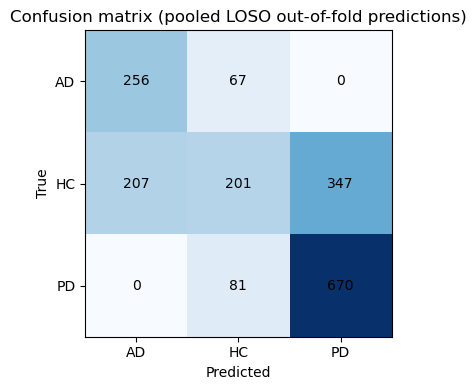

              precision    recall  f1-score   support

          AD       0.55      0.79      0.65       323
          HC       0.58      0.27      0.36       755
          PD       0.66      0.89      0.76       751

    accuracy                           0.62      1829
   macro avg       0.60      0.65      0.59      1829
weighted avg       0.61      0.62      0.58      1829



In [10]:
cm_df = plot_confusion_matrix(all_y_true, all_y_pred, label_encoder, OUTPUT_DIR)


## Step 9 - Final model + SHAP (interpretation only, not a performance claim)

`final_model` is fit on all data and used only for SHAP - performance metrics
come from the LOSO loop above.


Generating SHAP beeswarm for class: AD


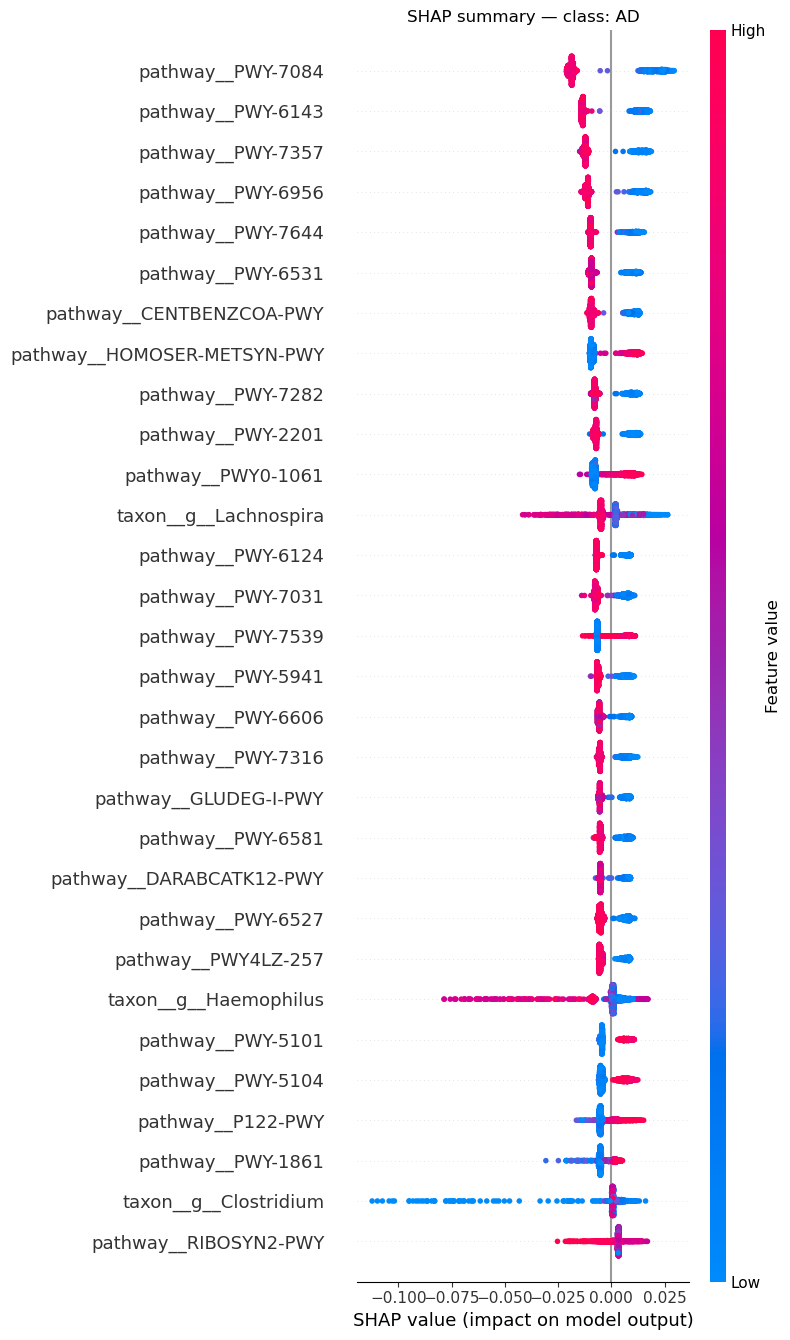

Generating SHAP beeswarm for class: HC


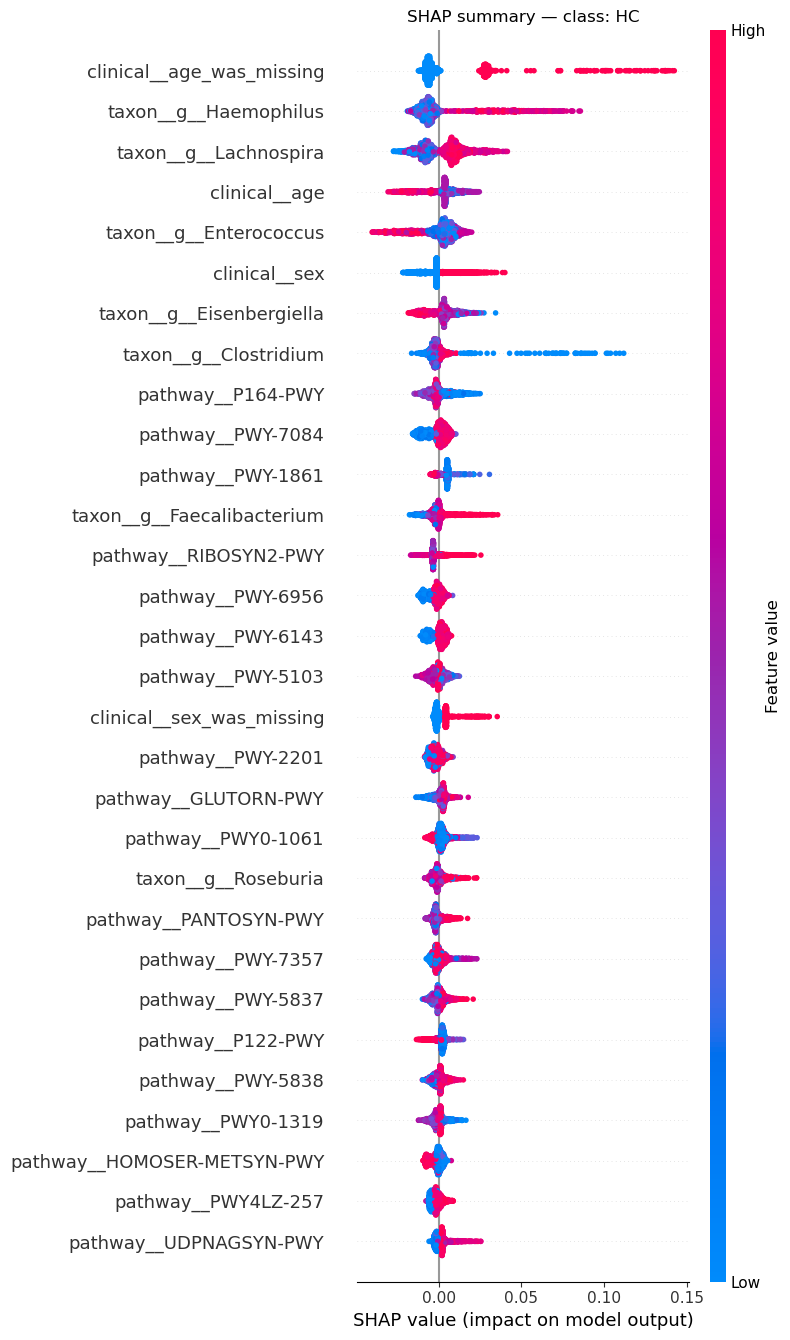

Generating SHAP beeswarm for class: PD


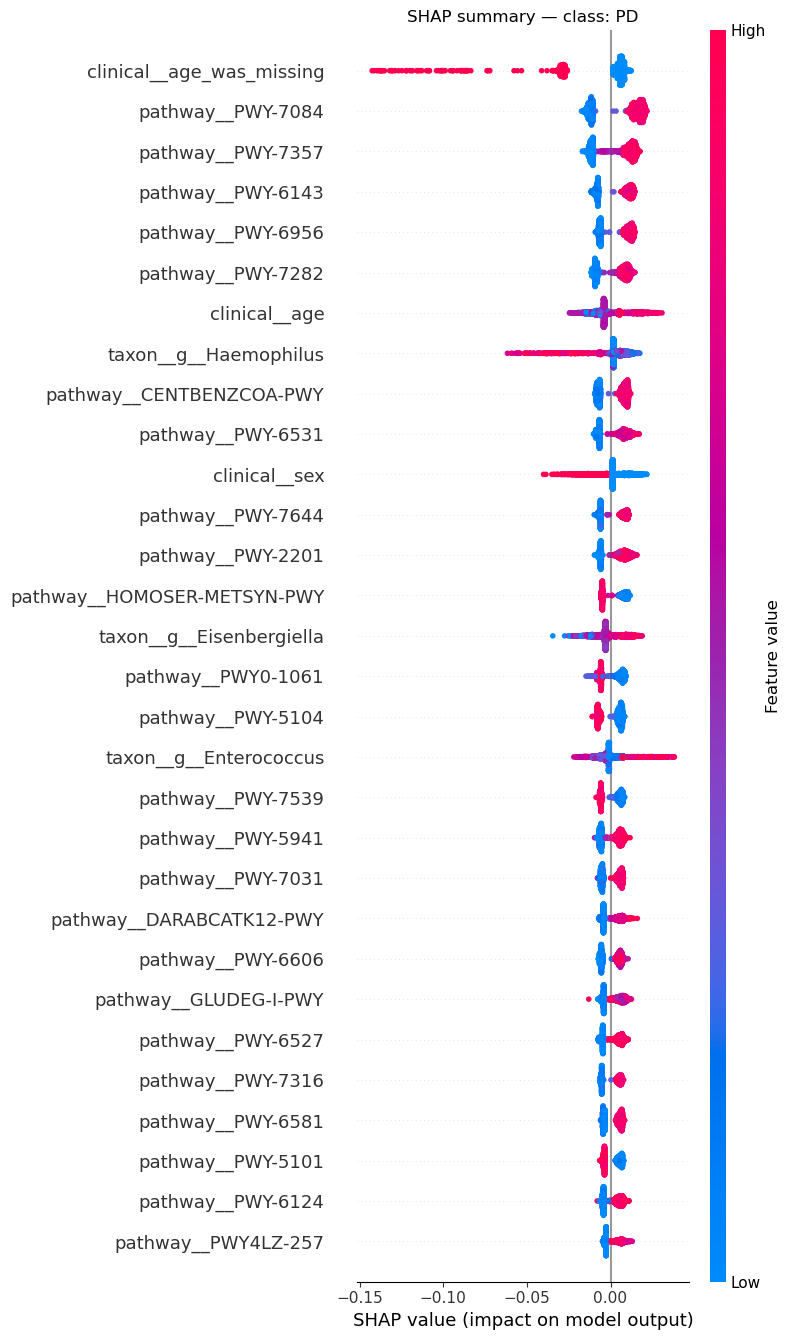

<Figure size 640x480 with 0 Axes>

In [11]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(**grid.best_params_, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_scaled, y)

shap_values = run_shap_analysis(final_model, X_scaled, feature_cols, label_encoder, OUTPUT_DIR,
                                 max_display=30 if len(feature_cols) > 40 else None)


## Step 10 - Save artefacts

In [12]:
save_artifacts(final_model, scaler, label_encoder, feature_cols, OUTPUT_DIR)


Saved model, scaler, label encoder, and feature list to: ml_config1_all_taxa
